# Layer 2 (Rebuilt): Two-Stage Road Condition Modeling

This notebook replaces prior Layer-2 analysis with a **two-stage pipeline**:

1. **Stage A (surface gate):** unpaved roads are assigned high poor-risk by policy.
2. **Stage B (paved-only model):** a 3-class classifier (`good`, `med`, `low`) for paved roads with Mapillary image-derived labels.

The model uses Sentinel-2 features + temporal trend features + optional problem/drainage features, and evaluates with grouped CV.


In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)



In [3]:
# Paths
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
XLSX_PATH = DATA_DIR / 'named_roads.xlsx'
SHEET = 'manual validation'

if not XLSX_PATH.exists():
    raise FileNotFoundError(f'Missing file: {XLSX_PATH}')

print('Workbook:', XLSX_PATH)


Workbook: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/named_roads.xlsx


In [4]:
# Load manual validation sheet
# Required columns (expected):
# osm_id, road_class, surface_class, road_name, region, pred_confidence, pred_condition

raw = pd.read_excel(XLSX_PATH, sheet_name=SHEET)
raw.columns = [str(c).strip() for c in raw.columns]
print('Rows:', len(raw), 'Cols:', len(raw.columns))
print('Head cols:', raw.columns[:20].tolist())


Rows: 17193 Cols: 91
Head cols: ['osm_id', 'road_class', 'surface_type', 'surface_class', 'road_name', 'region', 'image', 'image_date', 'pred_confidence', 'pred_condition', 'ndvi_2020_Q1', 'ndvi_2020_Q2', 'ndvi_2020_Q3', 'ndvi_2020_Q4', 'ndvi_2021_Q1', 'ndvi_2021_Q2', 'ndvi_2021_Q3', 'ndvi_2021_Q4', 'ndvi_2022_Q1', 'ndvi_2022_Q2']


In [5]:
# Normalize key fields
work = raw.copy()

for c in ['osm_id', 'road_class', 'surface_class', 'road_name', 'region', 'pred_condition', 'pred_confidence']:
    if c in work.columns:
        work[c] = work[c].astype(str).str.strip()

# keep only rows with condition labels from image pass
valid_cond = {'good', 'med', 'low'}
work['pred_condition_norm'] = work.get('pred_condition', '').astype(str).str.lower().str.strip()

# parse confidence numeric where present
if 'pred_confidence' in work.columns:
    work['pred_conf_num'] = pd.to_numeric(work['pred_confidence'], errors='coerce')
else:
    work['pred_conf_num'] = np.nan

# eligibility for Stage B
work['surface_norm'] = work.get('surface_class', '').astype(str).str.lower().str.strip()
work['is_paved'] = work['surface_norm'].eq('paved')
work['has_img_label'] = work['pred_condition_norm'].isin(valid_cond)

print('Paved rows:', int(work['is_paved'].sum()))
print('Rows with image condition labels:', int(work['has_img_label'].sum()))
print('Paved + image labels:', int((work['is_paved'] & work['has_img_label']).sum()))


Paved rows: 5668
Rows with image condition labels: 2096
Paved + image labels: 2096


In [6]:
# Build S2 feature list from available columns
# Expected format examples: ndvi_2020_Q1, ndmi_2021_Q3, ... bsi_2023_Q4

s2_pattern = re.compile(r'^(ndvi|ndmi|ndbi|ndwi|bsi)_(\d{4})_Q([1-4])$', re.I)
s2_cols = [c for c in work.columns if s2_pattern.match(str(c))]

if not s2_cols:
    raise ValueError('No S2 quarterly columns found. Check named_roads.xlsx columns.')

print('S2 quarterly cols:', len(s2_cols))
print('Sample:', s2_cols[:10])


S2 quarterly cols: 80
Sample: ['ndvi_2020_Q1', 'ndvi_2020_Q2', 'ndvi_2020_Q3', 'ndvi_2020_Q4', 'ndvi_2021_Q1', 'ndvi_2021_Q2', 'ndvi_2021_Q3', 'ndvi_2021_Q4', 'ndvi_2022_Q1', 'ndvi_2022_Q2']


In [7]:
# Temporal engineering: yearly means, QoQ deltas, YoY deltas, volatility

index_names = ['ndvi', 'ndmi', 'ndbi', 'ndwi', 'bsi']
years = sorted({int(s2_pattern.match(c).group(2)) for c in s2_cols})
quarters = [1, 2, 3, 4]

for idx in index_names:
    # year means
    for y in years:
        cols = [f'{idx}_{y}_Q{q}' for q in quarters if f'{idx}_{y}_Q{q}' in work.columns]
        if cols:
            work[f'{idx}_mean_y{y}'] = work[cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
            work[f'{idx}_std_y{y}'] = work[cols].apply(pd.to_numeric, errors='coerce').std(axis=1)

    # QoQ within year
    for y in years:
        for q in [2, 3, 4]:
            c_now = f'{idx}_{y}_Q{q}'
            c_prev = f'{idx}_{y}_Q{q-1}'
            if c_now in work.columns and c_prev in work.columns:
                work[f'{idx}_qoq_y{y}_Q{q}'] = pd.to_numeric(work[c_now], errors='coerce') - pd.to_numeric(work[c_prev], errors='coerce')

    # YoY same quarter
    for i in range(1, len(years)):
        y_prev = years[i-1]
        y_now = years[i]
        for q in quarters:
            c_now = f'{idx}_{y_now}_Q{q}'
            c_prev = f'{idx}_{y_prev}_Q{q}'
            if c_now in work.columns and c_prev in work.columns:
                work[f'{idx}_yoy_y{y_now}_Q{q}'] = pd.to_numeric(work[c_now], errors='coerce') - pd.to_numeric(work[c_prev], errors='coerce')

# Optional infrastructure/problem features if present
optional_numeric = [c for c in ['drains_n', 'culverts_n', 'bridges_n', 'Waterlogging', 'Erosion', 'Landslide'] if c in work.columns]

engineered_cols = [
    c for c in work.columns
    if any(c.startswith(f'{idx}_mean_') or c.startswith(f'{idx}_std_') or c.startswith(f'{idx}_qoq_') or c.startswith(f'{idx}_yoy_') for idx in index_names)
]

print('Engineered temporal cols:', len(engineered_cols))
print('Optional numeric cols:', optional_numeric)


Engineered temporal cols: 160
Optional numeric cols: []


In [8]:
# Stage B dataset: paved + labeled
stage_b = work[work['is_paved'] & work['has_img_label']].copy()

# targets
stage_b['target'] = stage_b['pred_condition_norm'].map({'good': 'good', 'med': 'med', 'low': 'low'})

# confidence filtering (optional): keep all rows with valid labels
# if you want high-confidence core set, uncomment:
# stage_b = stage_b[(stage_b['pred_conf_num'].isna()) | (stage_b['pred_conf_num'] >= 0.55)].copy()

# feature set
feature_cols = s2_cols + engineered_cols + optional_numeric + [c for c in ['road_class', 'region'] if c in stage_b.columns]
feature_cols = sorted(set(feature_cols))

# drop all-empty columns
keep = []
for c in feature_cols:
    s = stage_b[c]
    if s.notna().sum() > 0 and not (s.astype(str).str.strip().eq('').all()):
        keep.append(c)
feature_cols = keep

print('Stage B rows:', len(stage_b))
print('Target distribution:')
print(stage_b['target'].value_counts(dropna=False))
print('Feature columns:', len(feature_cols))


Stage B rows: 2096
Target distribution:
target
med     1623
low      394
good      79
Name: count, dtype: int64
Feature columns: 202


Fold metrics:


,fold,n_test,balanced_accuracy,macro_f1,weighted_f1
0,1,420,0.338528,0.322080,0.681688
1,2,419,0.345214,0.332693,0.684190
2,3,419,0.353854,0.348236,0.721199
3,4,419,0.343410,0.331462,0.675349
4,5,419,0.349187,0.334161,0.679882



CV summary (mean ± std):


,balanced_accuracy,macro_f1,weighted_f1
mean,0.346038,0.333726,0.688461
std,0.005809,0.009388,0.018584



Confusion matrix (rows=true, cols=pred), labels= ['good', 'med', 'low']
[[   0   74    5]
 [  10 1524   89]
 [   3  352   39]]


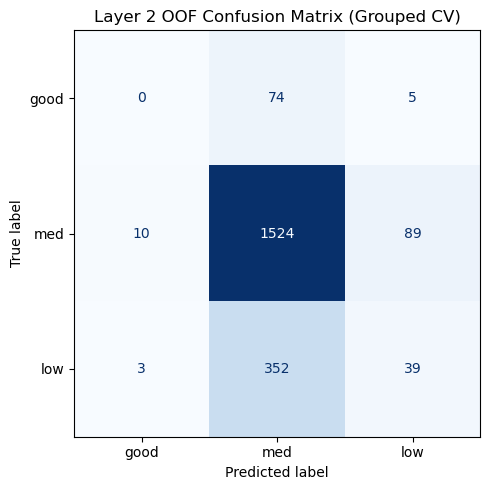


Classification report (pooled OOF):
              precision    recall  f1-score   support

        good      0.000     0.000     0.000        79
         med      0.782     0.939     0.853      1623
         low      0.293     0.099     0.148       394

    accuracy                          0.746      2096
   macro avg      0.358     0.346     0.334      2096
weighted avg      0.660     0.746     0.688      2096



In [9]:
# Grouped CV (by osm_id if available; fallback to road_name)
if 'osm_id' in stage_b.columns:
    groups = stage_b['osm_id'].astype(str)
elif 'road_name' in stage_b.columns:
    groups = stage_b['road_name'].astype(str)
else:
    groups = pd.Series(np.arange(len(stage_b)), index=stage_b.index).astype(str)

X = stage_b[feature_cols].copy()
y = stage_b['target'].copy()

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols),
    ],
    remainder='drop'
)

clf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced_subsample',
    min_samples_leaf=2,
    n_jobs=-1,
)

pipe = Pipeline([('pre', pre), ('rf', clf)])

gkf = GroupKFold(n_splits=5)

fold_rows = []
all_true, all_pred = [], []

for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
    Xtr, Xte = X.iloc[tr], X.iloc[te]
    ytr, yte = y.iloc[tr], y.iloc[te]

    pipe.fit(Xtr, ytr)
    yp = pipe.predict(Xte)

    all_true.extend(yte.tolist())
    all_pred.extend(yp.tolist())

    fold_rows.append({
        'fold': fold,
        'n_test': len(yte),
        'balanced_accuracy': balanced_accuracy_score(yte, yp),
        'macro_f1': f1_score(yte, yp, average='macro'),
        'weighted_f1': f1_score(yte, yp, average='weighted'),
    })

fold_df = pd.DataFrame(fold_rows)
print('Fold metrics:')
display(fold_df)
print('')
print('CV summary (mean ± std):')
display(fold_df[['balanced_accuracy','macro_f1','weighted_f1']].agg(['mean','std']))

labels = ['good','med','low']
cm = confusion_matrix(all_true, all_pred, labels=labels)
print('')
print('Confusion matrix (rows=true, cols=pred), labels=', labels)
print(cm)

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Layer 2 OOF Confusion Matrix (Grouped CV)')
plt.tight_layout()
plt.show()

print('')
print('Classification report (pooled OOF):')
print(classification_report(all_true, all_pred, labels=labels, digits=3))




In [10]:
# Fit final Stage B model on full paved+labeled set (for inference)
if 'pipe' not in globals() or 'X' not in globals() or 'y' not in globals():
    raise RuntimeError('Run the Grouped CV model cell first (it defines pipe, X, y).')

pipe.fit(X, y)

# Stage A + Stage B final risk outputs for full dataset
out = work.copy()
out['stageA_surface_gate'] = np.where(out['surface_norm'].eq('unpaved'), 'high_poor_risk_rule', 'paved_model_path')
out['stageB_condition'] = '-'
out['stageB_confidence'] = np.nan
out['final_poor_risk'] = '-'

# infer only for paved rows with features
paved_mask = out['surface_norm'].eq('paved')
Xp = out.loc[paved_mask, feature_cols].copy()

pred = pipe.predict(Xp)
out.loc[paved_mask, 'stageB_condition'] = pred

# confidence from RF probability max
proba = pipe.predict_proba(Xp)
out.loc[paved_mask, 'stageB_confidence'] = proba.max(axis=1)

# final risk mapping
# rule: unpaved -> high
# paved predicted low -> high risk; med -> medium risk; good -> low risk
out.loc[out['surface_norm'].eq('unpaved'), 'final_poor_risk'] = 'high'
out.loc[paved_mask & out['stageB_condition'].eq('low'), 'final_poor_risk'] = 'high'
out.loc[paved_mask & out['stageB_condition'].eq('med'), 'final_poor_risk'] = 'medium'
out.loc[paved_mask & out['stageB_condition'].eq('good'), 'final_poor_risk'] = 'low'

print('Final risk distribution:')
print(out['final_poor_risk'].value_counts(dropna=False))

keep_cols = [c for c in ['osm_id','road_name','road_class','region','surface_class','pred_condition','pred_confidence'] if c in out.columns]
keep_cols += ['stageA_surface_gate','stageB_condition','stageB_confidence','final_poor_risk']

display(out[keep_cols].head(20))



Final risk distribution:
final_poor_risk
-         10134
medium     4967
high       1989
low         103
Name: count, dtype: int64


,osm_id,road_name,road_class,region,surface_class,pred_condition,pred_confidence,stageA_surface_gate,stageB_condition,stageB_confidence,final_poor_risk
0,256102639,10th Avenue,unclassified,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
1,630102193,10th Avenue,residential,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
2,340533048,10th Lane,residential,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
3,29696019,10th Street,residential,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
4,475366065,10th Street,residential,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
5,1489808362,11th Avenue,residential,nan,unknown,-,-,paved_model_path,-,NaN,-
6,1489808363,11th Avenue,residential,nan,unknown,-,-,paved_model_path,-,NaN,-
7,226557739,11th Avenue,residential,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
8,340533126,11th Avenue,residential,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
9,448833054,11th Avenue,residential,Greater Accra,unknown,-,-,paved_model_path,-,NaN,-
